<a href="https://colab.research.google.com/github/sl007ha/qqq-risk-monitor/blob/main/notebooks/05_aaii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd

# 上传后的文件路径
aaii_raw = pd.read_excel('/content/sentiment.xls', sheet_name=0, header=None)
print(aaii_raw.head(10))

                    0        1        2   \
0                  NaN      NaN      NaN   
1                  NaN      NaN      NaN   
2             Reported      NaN      NaN   
3                 Date  Bullish  Neutral   
4                  NaN      NaN      NaN   
5  1987-06-26 00:00:00      NaN      NaN   
6  1987-07-17 00:00:00      NaN      NaN   
7  1987-07-24 00:00:00     0.36      0.5   
8  1987-07-31 00:00:00     0.26     0.48   
9  1987-08-07 00:00:00     0.56     0.15   

                                                  3      4        5   \
0  American Association of Individual Investors 6...    NaN      NaN   
1                                                NaN    NaN  Bullish   
2                                                NaN    NaN   8-week   
3                                            Bearish  Total  Mov Avg   
4                                                NaN    NaN      NaN   
5                                                NaN    NaN      NaN   
6          

In [27]:
# 找出真正的 header 行——一般是包含 'Date', 'Bullish', 'Bearish' 字样的那一行
for i, row in aaii_raw.head(15).iterrows():
    if 'Bullish' in row.astype(str).values or 'Date' in row.astype(str).values:
        print(f"Header 行：{i}")
        print(row.values)
        break

Header 行：1
[nan nan nan nan nan 'Bullish' nan nan 'Bullish' 'Bullish' 'S&P 500'
 'S&P 500' 'S&P 500' nan]


In [28]:
aaii = pd.read_excel('/content/sentiment.xls', sheet_name=0, skiprows=3)
print(aaii.columns.tolist())
print(aaii.head())

['Date', 'Bullish', 'Neutral', 'Bearish', 'Total', 'Mov Avg', 'Spread', 'Average', '+St. Dev.', '- St. Dev.', 'High', 'Low', 'Close', 'Unnamed: 13']
                  Date  Bullish  Neutral  Bearish  Total  Mov Avg  Spread  \
0                  NaN      NaN      NaN      NaN    NaN      NaN     NaN   
1  1987-06-26 00:00:00      NaN      NaN      NaN    NaN      NaN     NaN   
2  1987-07-17 00:00:00      NaN      NaN      NaN    NaN      NaN     NaN   
3  1987-07-24 00:00:00     0.36     0.50     0.14    1.0      NaN    0.22   
4  1987-07-31 00:00:00     0.26     0.48     0.26    1.0      NaN    0.00   

   Average  +St. Dev.  - St. Dev.    High     Low   Close Unnamed: 13  
0      NaN        NaN         NaN     NaN     NaN     NaN         NaN  
1  0.37623   0.476341    0.276119     NaN     NaN     NaN         NaN  
2  0.37623   0.476341    0.276119  314.59  307.63  314.59         NaN  
3  0.37623   0.476341    0.276119  311.39  307.81  309.27         NaN  
4  0.37623   0.476341    0.2

In [29]:
# 通常列是 ['Reported Date', 'Bullish', 'Neutral', 'Bearish', ...]
# 可能列名带空格或大小写不同，根据你看到的实际情况调整下面这行

# 重命名核心列
col_map = {}
for c in aaii.columns:
    cl = str(c).lower().strip()
    if 'date' in cl:
        col_map[c] = 'date'
    elif 'bull' in cl and 'high' not in cl and 'low' not in cl and '8' not in cl:
        col_map[c] = 'bullish'
    elif 'bear' in cl and 'high' not in cl and 'low' not in cl and '8' not in cl:
        col_map[c] = 'bearish'
    elif 'neutral' in cl and 'high' not in cl and '8' not in cl:
        col_map[c] = 'neutral'

aaii = aaii.rename(columns=col_map)
aaii = aaii[['date', 'bullish', 'neutral', 'bearish']].dropna()
aaii['date'] = pd.to_datetime(aaii['date'], errors='coerce')
aaii = aaii.dropna(subset=['date']).set_index('date').sort_index()

# Bullish/Bearish 可能是 0–1 小数（如 0.45）也可能是 0–100 百分数（如 45）
# 看一下范围
print(aaii.describe())

# 如果是小数，乘 100 转成百分数
if aaii['bullish'].max() < 1.5:
    aaii[['bullish', 'neutral', 'bearish']] *= 100

aaii['bb_spread'] = aaii['bullish'] - aaii['bearish']
print(aaii.tail())

           bullish      neutral      bearish
count  2022.000000  2022.000000  2022.000000
mean      0.376230     0.310447     0.313323
std       0.100111     0.081399     0.098512
min       0.120000     0.076900     0.060000
25%       0.303475     0.251885     0.240793
50%       0.372666     0.310000     0.300000
75%       0.440000     0.365591     0.374438
max       0.750000     0.620000     0.702700
            bullish  neutral  bearish  bb_spread
date                                            
2026-04-09  35.7466  21.2670  42.9864    -7.2398
2026-04-16  31.7308  25.4808  42.7885   -11.0577
2026-04-23  46.0465  19.5349  34.4186    11.6279
2026-04-30  38.1323  22.1790  39.6887    -1.5564
2026-05-07  38.3142  28.7356  32.9502     5.3640


In [30]:
# 月末值 = 当月最后一周的数据
aaii_m = aaii[['bb_spread', 'bullish', 'bearish']].resample('ME').last()
aaii_m = aaii_m.dropna()
print(aaii_m.tail())
print(f"AAII 数据从 {aaii_m.index.min()} 到 {aaii_m.index.max()}，共 {len(aaii_m)} 个月")

            bb_spread  bullish  bearish
date                                   
2026-01-31    13.6000  44.4000  30.8000
2026-02-28    -6.5574  33.1967  39.7541
2026-03-31   -17.6954  32.0988  49.7942
2026-04-30    -1.5564  38.1323  39.6887
2026-05-31     5.3640  38.3142  32.9502
AAII 数据从 1987-07-31 00:00:00 到 2026-05-31 00:00:00，共 467 个月


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20048 (\N{CJK UNIFIED IDEOGRAPH-4E50}) missing from font(s) DejaVu Sans.
  fig.canvas

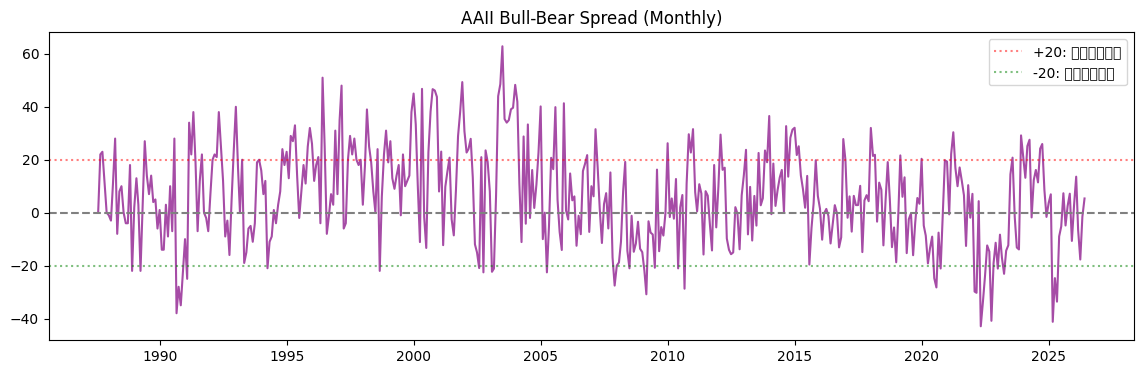

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(aaii_m.index, aaii_m['bb_spread'], color='purple', alpha=0.7)
ax.axhline(0, color='gray', linestyle='--')
ax.axhline(20, color='red', linestyle=':', alpha=0.5, label='+20: 散户过度乐观')
ax.axhline(-20, color='green', linestyle=':', alpha=0.5, label='-20: 散户过度悲观')
ax.legend()
ax.set_title('AAII Bull-Bear Spread (Monthly)')
plt.show()

In [32]:
aaii_m[['bb_spread']].to_csv('/content/aaii.csv')